# Cartographie sémantique des publications de la FSBM
### Pipeline reproductible : données collectées → contrôle et nettoyage → vectorisation → recherche → cartographie

Ce notebook reprend le déroulement du notebook de référence avec **une implémentation différente** : TF-IDF, projection SVD et MiniBatch K-Means, sans service externe. Il exploite les données déjà collectées fournies dans `data/fsbm_dataset.json`. Il **ne relance pas** une collecte OpenAlex ou Google Scholar.

| Étape | Entrée / outil | Résultat |
|---|---|---|
| 1. Données collectées | `data/fsbm_dataset.json` | chercheurs et publications attribuées |
| 2. Contrôle et nettoyage | `engine.extract_records` | publications uniques, qualité des champs |
| 3. Vectorisation | `engine.Atlas` | TF-IDF + SVD, représentation latente |
| 4. Recherche | `Atlas.search` | articles et chercheurs proches d'une requête |
| 5. Cartographie | `Atlas.points`, `Atlas.topics` | projection en 2D, thèmes et départements |
| 6. Bilan | statistiques calculées | limites et pistes d'amélioration |

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "engine.py").is_file():
    ROOT = ROOT.parent
if not (ROOT / "engine.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter à la racine du projet ou dans notebooks/")
sys.path.insert(0, str(ROOT))
from engine import DATA, Atlas, extract_records
pd.set_option("display.max_colwidth", 100)
print("Projet :", ROOT)
print("Jeu de données :", DATA.relative_to(ROOT))

Projet : /workspace/scratch/b60c06139b47/cartographie-fsbm-alternative
Jeu de données : data/fsbm_dataset.json


## 1. Examiner les données collectées

L'archive du projet contient le résultat d'une collecte préalable. On consulte ses métadonnées, sa liste de chercheurs et un exemple de publication. L'origine renseignée dans chaque article est informative ; les métadonnées ont les limites de qualité de leurs sources.

In [2]:
dataset = json.loads(DATA.read_text(encoding="utf-8"))
print("Institution :", dataset.get("institution"))
print("Date de génération :", dataset.get("generated_at"))
print("Chercheurs :", len(dataset["chercheurs"]))
print("Publications uniques déclarées :", dataset.get("nb_articles_uniques"))
researchers_table = pd.DataFrame([{
    "nom": r["nom_complet"], "département": r.get("departement"),
    "articles attribués": len(r.get("articles") or []),
    "h-index déclaré": (r.get("metriques") or {}).get("h_index")
} for r in dataset["chercheurs"]])
display(researchers_table.head(30))

Institution : Faculty of Sciences Ben M'Sik, Hassan II University, Casablanca
Date de génération : 2026-09-15T23:04:04.290550+00:00
Chercheurs : 30
Publications uniques déclarées : 4208
                     nom  ... h-index déclaré
0            Said Broumi  ...              36
1           Samir Chtita  ...              38
2        Hassan Hannache  ...              34
3            Saı̈d Sebti  ...              35
4          Khalid Hattaf  ...              33
5       Mohammed Berrada  ...              32
6          Mohamed Talea  ...              27
7         Mohammed Talbi  ...              26
8       Noureddine Damil  ...              30
9           Noura Yousfi  ...              27
10          A. El Bouari  ...              18
11    Abdeslam El Bouari  ...              27
12          Y. Boughaleb  ...              22
13        Mostafa Rachik  ...              25
14  Mohamed El Guendouzi  ...              20
15          Saïd Ouaskit  ...              21
16            Saïd Gmouh  ...   

In [3]:
example = dataset["chercheurs"][0]["articles"][0]
display({key: example.get(key) for key in
         ["titre", "annee", "auteurs", "doi", "sources", "abstract_source", "citations"]})

{'titre': 'Correlation Coefficient of Interval Neutrosophic Set', 'annee': 2013, 'auteurs': ['Said Broumi', 'Florentín Smarandache'], 'doi': '10.4028/www.scientific.net/amm.436.511', 'sources': ['openalex'], 'abstract_source': 'openalex', 'citations': 164}


### Provenance des publications

On compte les valeurs déjà consignées dans `sources`. Ce tableau indique la provenance **déclarée dans le fichier**, pas le résultat d'un nouveau scraping.

In [4]:
from collections import Counter
provenance = Counter()
for researcher in dataset["chercheurs"]:
    for article in researcher.get("articles") or []:
        provenance.update(article.get("sources") or [article.get("source") or "non renseignée"])
display(pd.DataFrame(provenance.most_common(), columns=["source déclarée", "occurrences (avec doublons)"]))

  source déclarée  occurrences (avec doublons)
0        openalex                         4537
1  google_scholar                         1236


## 2. Contrôle et structuration

Un même article peut figurer dans plusieurs profils. `extract_records` le regroupe par identifiant d'article, puis DOI, puis titre + année si ces identifiants manquent. Il associe ensuite les chercheurs à chaque publication. Ce contrôle n'affirme pas avoir refait la normalisation ou le filtrage des homonymes en amont.

In [5]:
papers, people = extract_records(DATA)
raw_count = sum(len(r.get("articles") or []) for r in dataset["chercheurs"])
quality = pd.DataFrame([{
    "lignes d'articles dans les profils": raw_count,
    "articles uniques indexés": len(papers),
    "attributions répétées": raw_count - len(papers),
    "chercheurs": len(people),
    "avec résumé": sum(bool(p["abstract"].strip()) for p in papers),
    "avec année": sum(isinstance(p["year"], int) for p in papers),
    "avec mots-clés": sum(bool(p["keywords"]) for p in papers),
}])
display(quality)

   lignes d'articles dans les profils  ...  avec mots-clés
0                                4781  ...            3922

[1 rows x 7 columns]


In [6]:
display(pd.DataFrame(papers)[["title", "year", "citations", "researchers"]].head(8))
print("Exemple :", papers[0]["title"])
print("Résumé :", papers[0]["abstract"][:350] or "aucun")

                                                                                             title  ...                 researchers
0                                             Correlation Coefficient of Interval Neutrosophic Set  ...               [A5054208274]
1                                                 Several Similarity Measures Of Neutrosophic Sets  ...               [A5054208274]
2                                        Single valued neutrosophic graphs: Degree, order and size  ...  [A5054208274, A5057080990]
3                   Neutrosophic soft sets and neutrosophic soft matrices based on decision making  ...               [A5054208274]
4                       Applying Dijkstra algorithm for solving neutrosophic shortest path problem  ...  [A5054208274, A5057080990]
5  Fusion of engineering insights and emerging trends: Intelligent urban traffic management system  ...  [A5054208274, A5057080990]
6                                                         Neutrosophic graph

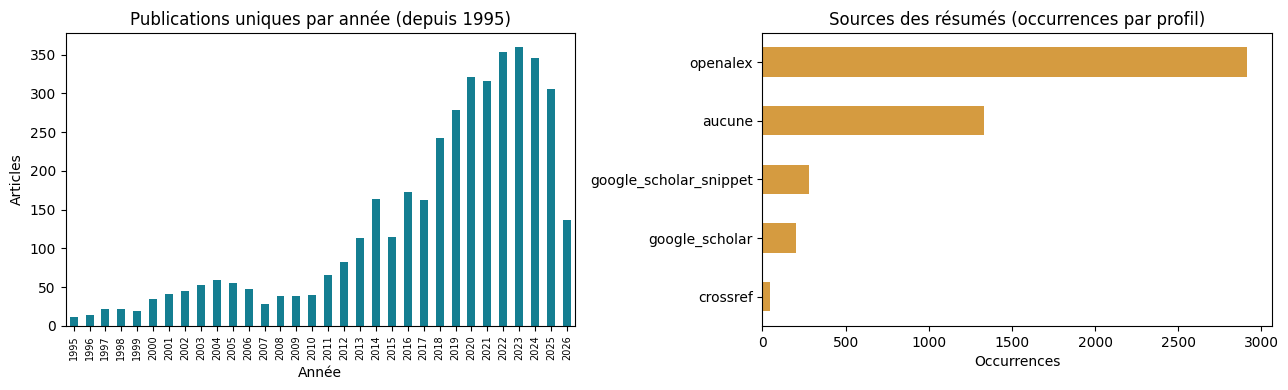

In [7]:
years = pd.Series([p["year"] for p in papers if isinstance(p["year"], int)])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
years.value_counts().sort_index().loc[1995:].plot.bar(ax=axes[0], color="#147e91")
axes[0].set(title="Publications uniques par année (depuis 1995)", xlabel="Année", ylabel="Articles")
axes[0].tick_params(axis="x", labelrotation=90, labelsize=7)
source_counts = Counter((a.get("abstract_source") or "aucune") for r in dataset["chercheurs"] for a in r.get("articles") or [])
pd.Series(source_counts).sort_values().plot.barh(ax=axes[1], color="#d59b40")
axes[1].set(title="Sources des résumés (occurrences par profil)", xlabel="Occurrences")
plt.tight_layout()
plt.show()

## 3. Vectorisation et groupes thématiques

Le texte combine titre, extrait de résumé et mots-clés. `Atlas` crée une matrice TF-IDF de termes anglais, la réduit avec SVD et normalise les vecteurs. MiniBatch K-Means forme les groupes. Cette **analyse sémantique latente** dépend des mots du corpus ; ce ne sont pas les embeddings multilingues du notebook de référence.

In [8]:
atlas = Atlas(DATA)
summary = atlas.overview()
print("Articles :", summary["papers"], "| Chercheurs :", summary["researchers"])
print("Taille des vecteurs :", atlas.vectors.shape)
print("Vocabulaire TF-IDF :", len(atlas.vectorizer.get_feature_names_out()))
print("Dimensions SVD :", getattr(atlas.reducer, "n_components", "non applicable"))
print("Norme moyenne :", round(float(np.linalg.norm(atlas.vectors, axis=1).mean()), 3))

Articles : 4208 | Chercheurs : 30
Taille des vecteurs : (4208, 64)
Vocabulaire TF-IDF : 18000
Dimensions SVD : 64
Norme moyenne : 1.0


In [9]:
topics_table = pd.DataFrame(summary["topics"])
display(topics_table[["id", "name", "count", "terms"]].sort_values("count", ascending=False))

   id  ...                                              terms
1   1  ...  [materials, materials science, chemistry, energy]
0   0  ...       [learning, data, computer, computer science]
3   3  ...          [molecular, docking, activity, compounds]
4   4  ...                [neutrosophic, fuzzy, valued, sets]
6   6  ...             [method, computer, quantum, algorithm]
5   5  ...         [control, optimal, optimal control, model]
2   2  ...               [model, infection, virus, stability]
7   7  ...                    [dans, pour, etude, humanities]
8   8  ...         [chemistry, phosphate, catalysis, organic]

[9 rows x 4 columns]


## 4. Recherche par similarité

La requête passe par le même TF-IDF puis la même projection SVD. Les résultats sont triés selon la similarité cosinus dans cet espace. Les scores servent à classer les résultats du corpus et n'estiment pas une pertinence absolue.

In [10]:
def show_articles(query, limit=6, **filters):
    response = atlas.search(query=query, limit=limit, **filters)
    print(f"{response['total']} résultat(s) avec score positif pour {query!r}")
    display(pd.DataFrame([{
        "année": p["year"], "titre": p["title"],
        "score": p["score"], "citations": p["citations"]
    } for p in response["items"]]))

show_articles("deep learning medical imaging", 8)

2592 résultat(s) avec score positif pour 'deep learning medical imaging'
   année  ... citations
0   2021  ...         7
1   2021  ...        26
2   2024  ...         0
3   2024  ...        12
4   2024  ...         0
5   2021  ...        18
6   2021  ...        14
7   2023  ...         3

[8 rows x 4 columns]


In [11]:
show_articles("neutrosophic sets and graph theory", 6)
show_articles("organic chemistry catalysis", 6)

2803 résultat(s) avec score positif pour 'neutrosophic sets and graph theory'
   année  ... citations
0   2014  ...        22
1   2018  ...         3
2   2014  ...       100
3   2026  ...         0
4   2026  ...         0
5   2020  ...         0

[6 rows x 4 columns]
2700 résultat(s) avec score positif pour 'organic chemistry catalysis'
   année  ... citations
0   2003  ...        15
1   2005  ...        15
2   2006  ...        40
3   2005  ...        41
4   2003  ...         0
5   2001  ...        59

[6 rows x 4 columns]


### Chercheurs proches d'un sujet

Cette fonction originale agrège, pour chaque chercheur, le meilleur score de ses publications et la moyenne de ses trois meilleurs scores. Les articles coécrits peuvent donc contribuer à plusieurs chercheurs.

In [12]:
def researcher_matches(query, limit=8):
    q = atlas.vectorizer.transform([query])
    from sklearn.preprocessing import normalize
    from sklearn.metrics.pairwise import cosine_similarity
    v = normalize(atlas.reducer.transform(q)) if atlas.reducer else q
    scores = cosine_similarity(v, atlas.vectors).ravel()
    index = {p["id"]: p["name"] for p in atlas.researchers}
    associated = {rid: [] for rid in index}
    for paper, score in zip(atlas.papers, scores):
        for rid in paper["researchers"]:
            if rid in associated:
                associated[rid].append(float(score))
    ranked = []
    for rid, values in associated.items():
        if not values:
            continue
        best = sorted(values, reverse=True)[:3]
        ranked.append({"chercheur": index[rid], "score composite": round(.7 * best[0] + .3 * np.mean(best), 4),
                       "articles attribués": len(values)})
    return pd.DataFrame(ranked).sort_values("score composite", ascending=False).head(limit)

display(researcher_matches("machine learning artificial intelligence"))

               chercheur  score composite  articles attribués
6          Mohamed Talea           0.9393                 240
13        Mostafa Rachik           0.8895                 213
22      Faouzia Benabbou           0.8517                 106
15          Saïd Ouaskit           0.8384                 105
25  Abdessamad Belangour           0.8256                 120
18    El Habib Benlahmar           0.8125                 152
24            Bennai, M.           0.7413                 145
0            Said Broumi           0.7390                 569


In [13]:
display(researcher_matches("catalysis organic synthesis", 6))
# Les filtres s'appliquent à la même recherche.
person = summary["people"][0]
print("Exemple de filtre :", person["name"])
display(pd.DataFrame(atlas.search(researcher=person["id"], year=2020, limit=5)["items"])[["title", "year"]])

               chercheur  score composite  articles attribués
3            Saı̈d Sebti           0.9529                 149
16            Saïd Gmouh           0.8720                 145
11    Abdeslam El Bouari           0.8213                 151
1           Samir Chtita           0.8060                 321
14  Mohamed El Guendouzi           0.7615                  90
7         Mohammed Talbi           0.7452                 219
Exemple de filtre : Said Broumi
                                                                                                 title  year
0  Single and Multi-valued Neutrosophic Hypersoft set and Tangent Similarity Measure of Single valu...  2020
1                                               COMBINATORIAL TECHNIQUE FOR OPTIMIZING THE COMBINATION  2020
2                                        Triangular interval type-2 fuzzy soft set and its application  2020
3                  Intelligent algorithm for trapezoidal interval valued neutrosophic network anal

## 5. Cartographie sémantique

Les coordonnées représentent les deux premières dimensions SVD normalisées et recentrées. Les couleurs sont les groupes K-Means. Cette carte sert à explorer les voisins **dans cette projection** : des distances en 2D peuvent différer des similarités calculées dans l'espace complet.

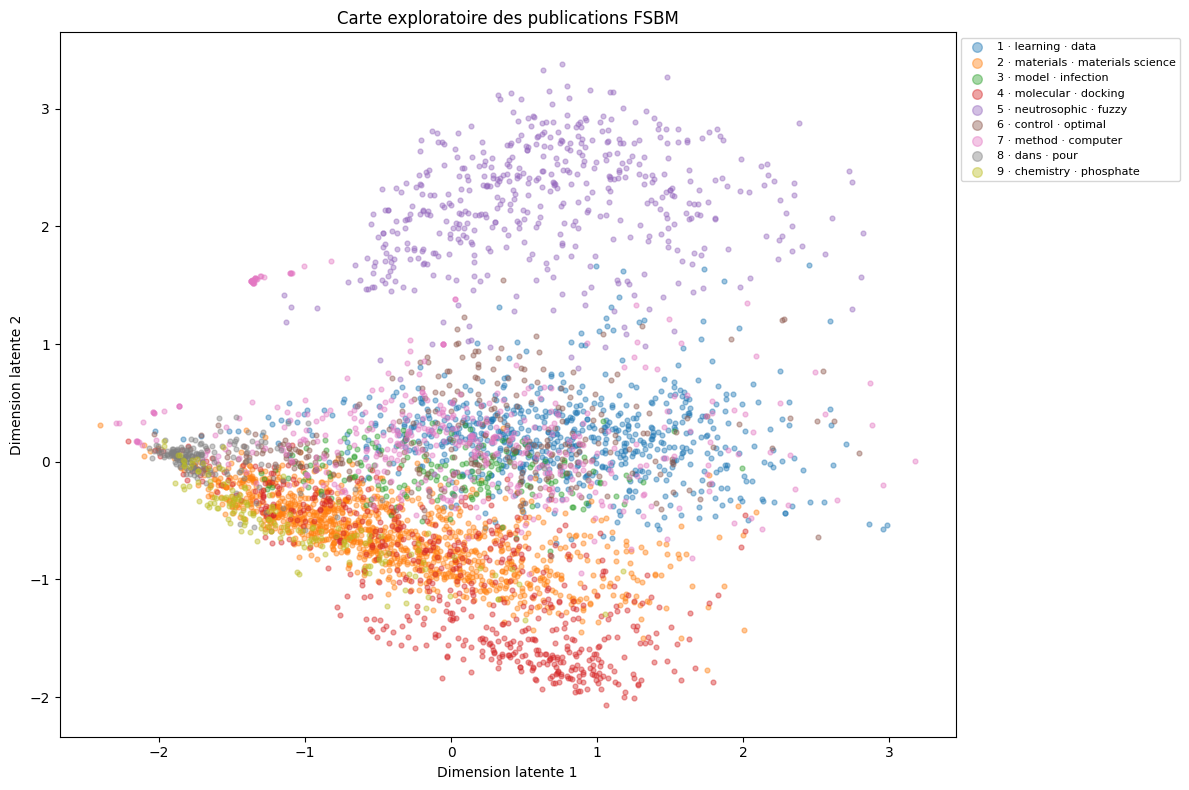

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))
for topic in summary["topics"]:
    group = [p for p in atlas.points if p["cluster"] == topic["id"]]
    ax.scatter([p["x"] for p in group], [p["y"] for p in group], s=12, alpha=.42,
               label=f"{topic['id'] + 1} · {topic['name'][:29]}")
ax.set(title="Carte exploratoire des publications FSBM", xlabel="Dimension latente 1", ylabel="Dimension latente 2")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

In [15]:
departments = {r["id"]: r["department"] for r in atlas.researchers}
rows = []
for paper, point in zip(atlas.papers, atlas.points):
    departments_for_paper = {departments.get(rid, "Non renseigné") for rid in paper["researchers"]}
    for department in departments_for_paper:
        rows.append({"département": department, "groupe": point["cluster"] + 1})
by_department = pd.crosstab(pd.DataFrame(rows)["département"], pd.DataFrame(rows)["groupe"])
print("Une publication coattribuée à plusieurs départements figure dans chaque département concerné.")
display(by_department)

Une publication coattribuée à plusieurs départements figure dans chaque département concerné.
groupe                           1    2    3    4    5    6    7   8    9
département                                                              
Biologie                        15    4    6  170    0    0    1  30    1
Chimie                         139  558    1  365    7    1   32  60  152
Mathématiques et Informatique  531   11  176    2  484  213  145  20    0
Physique                        16  612    0   25    2   79  286  67   15


## 6. Bilan

- **Données** : le notebook analyse le fichier fourni, sans nouvelle collecte ni appels réseau.
- **Préparation** : les publications sont regroupées par identifiant, DOI ou titre et année ; les métriques et l'attribution initiales proviennent du fichier fourni.
- **Modèle** : TF-IDF + SVD favorise les termes observés dans le corpus ; les requêtes françaises ne bénéficient pas d'un modèle multilingue.
- **Carte** : la projection 2D et les noms automatiques de groupes sont exploratoires et demandent une validation humaine.

Pour lancer aussi l'application interactive : à la racine du projet, exécuter `python server.py`. La démonstration reste autonome et utilise le même `engine.py`.

In [16]:
print(f"Bilan calculé : {len(atlas.researchers)} chercheurs, {len(atlas.papers)} articles uniques, "
      f"{len(atlas.topics)} groupes, {sum(bool(p['abstract'].strip()) for p in atlas.papers)} résumés disponibles.")

Bilan calculé : 30 chercheurs, 4208 articles uniques, 9 groupes, 3032 résumés disponibles.
